In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Load the cleaned data
file_path = r"C:\Users\Tejas\Desktop\hybrid_recommender\data\processed\cleaned_reviews.csv"
print("Loading data...")
df = pd.read_csv(file_path)

# We need to know the total number of unique users and items to size our matrices
num_users = df['user_id_int'].nunique()
num_items = df['item_id_int'].nunique()
print(f"Total Unique Users: {num_users}")
print(f"Total Unique Items: {num_items}")

# 2. Split the data into Training (80%) and Validation (20%) sets
# We must test the model on data it has never seen to prove it actually works
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Create the PyTorch Dataset blueprint
class AmazonReviewDataset(Dataset):
    def __init__(self, dataframe):
        # Convert pandas columns to PyTorch tensors
        self.users = torch.tensor(dataframe['user_id_int'].values, dtype=torch.long)
        self.items = torch.tensor(dataframe['item_id_int'].values, dtype=torch.long)
        # Ratings must be float32 for calculating Mean Squared Error loss
        self.ratings = torch.tensor(dataframe['Score'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# 4. Instantiate the Datasets and DataLoaders
train_dataset = AmazonReviewDataset(train_df)
val_dataset = AmazonReviewDataset(val_df)

# Batch size of 1024 is highly efficient for a GTX 1650 on tabular data
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

print("PyTorch DataLoaders are ready!")

c:\Users\Tejas\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading data...
Total Unique Users: 256059
Total Unique Items: 74258
PyTorch DataLoaders are ready!


In [2]:
import torch.nn as nn

class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super(MatrixFactorization, self).__init__()
        
        # 1. The User Matrix (U)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        # User Bias: accounts for users who tend to rate consistently high or low
        self.user_bias = nn.Embedding(num_users, 1)
        
        # 2. The Item Matrix (V)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        # Item Bias: accounts for items that are universally loved or hated
        self.item_bias = nn.Embedding(num_items, 1)
        
        # 3. Global Bias: The average rating across the entire dataset
        self.global_bias = nn.Parameter(torch.zeros(1))
        
        # Initialize the weights with small random numbers to start the learning process
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_ids, item_ids):
        # Step A: Look up the 32-number vectors for these specific users and items
        u = self.user_embedding(user_ids)
        i = self.item_embedding(item_ids)
        
        # Step B: Look up the 1-number bias for these users and items
        u_bias = self.user_bias(user_ids).squeeze()
        i_bias = self.item_bias(item_ids).squeeze()
        
        # Step C: The Core Math - Dot Product of User and Item vectors
        # We multiply element-wise, then sum across the 32 dimensions
        dot_product = (u * i).sum(dim=1)
        
        # Step D: Add the biases to get the final predicted rating
        prediction = dot_product + u_bias + i_bias + self.global_bias
        
        return prediction

# Instantiate the model using the variables we calculated in Cell 1
embedding_size = 32
model = MatrixFactorization(num_users, num_items, embedding_dim=embedding_size)

print("PyTorch SVD Model Architecture Built!")
print(model)

PyTorch SVD Model Architecture Built!
MatrixFactorization(
  (user_embedding): Embedding(256059, 32)
  (user_bias): Embedding(256059, 1)
  (item_embedding): Embedding(74258, 32)
  (item_bias): Embedding(74258, 1)
)


In [3]:
import torch.optim as optim

# 1. Hardware Optimization: Send the model to the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")
model = model.to(device)

# 2. Define the exact Loss Function and Optimizer
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.005) # lr is the Learning Rate

# 3. Setup tracking variables
epochs = 5 # We pass through the entire dataset 5 times
train_losses = []
val_losses = []

print("Starting Training Loop...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Tells PyTorch we are actively learning
    total_train_loss = 0
    
    # Iterate through the batches generated by our DataLoader
    for users, items, ratings in train_loader:
        # Move data to the same device as the model
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        
        # Zero out the old gradients from the last step
        optimizer.zero_grad()
        
        # Forward Pass: Make a prediction
        predictions = model(users, items)
        
        # Calculate the error
        loss = criterion(predictions, ratings)
        
        # Backward Pass: Calculate the gradients (Calculus)
        loss.backward()
        
        # Update the embedding weights
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval() # Turn off learning mode
    total_val_loss = 0
    
    with torch.no_grad(): # Shut off the autograd engine to save memory
        for users, items, ratings in val_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            
            predictions = model(users, items)
            loss = criterion(predictions, ratings)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("Training Complete!")

Training on device: cuda
Starting Training Loop...
Epoch 1/5 | Train Loss: 9.9615 | Val Loss: 4.1663
Epoch 2/5 | Train Loss: 2.0837 | Val Loss: 1.9583
Epoch 3/5 | Train Loss: 0.4035 | Val Loss: 1.7486
Epoch 4/5 | Train Loss: 0.0933 | Val Loss: 1.7182
Epoch 5/5 | Train Loss: 0.0589 | Val Loss: 1.7358
Training Complete!


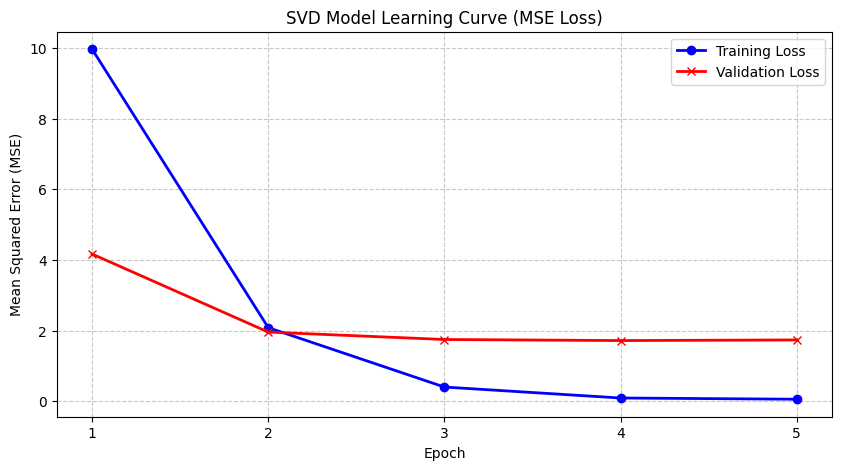

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Plotting both lines
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', marker='x', linewidth=2)

# Styling for a professional look
plt.title('SVD Model Learning Curve (MSE Loss)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [5]:
import os

# 1. Define the save path
model_dir = r"C:\Users\Tejas\Desktop\hybrid_recommender\models"
save_path = os.path.join(model_dir, "svd_model.pth")

# 2. Ensure the models directory actually exists
os.makedirs(model_dir, exist_ok=True)

# 3. Save the PyTorch state dictionary (the learned weights)
torch.save(model.state_dict(), save_path)

print(f"Success! Model weights saved to: {save_path}")

Success! Model weights saved to: C:\Users\Tejas\Desktop\hybrid_recommender\models\svd_model.pth
